In [1]:
# ==========================================
# Step 1 : Import Required Libraries
# ==========================================

import os
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torchvision import transforms
from torchvision.models import efficientnet_b0

from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("=" * 60)
print("✅ All Libraries Imported Successfully")
print("=" * 60)

✅ All Libraries Imported Successfully


In [2]:
# ==========================================
# Step 2 : Define Project Paths
# ==========================================

import os
import torch

# Test Dataset
TEST_DIR = r"D:\major project\dataset_split\test"

# Best Model
MODEL_PATH = r"D:\major project\models\best_efficientnetb0.pth"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Test Dataset Exists :", os.path.exists(TEST_DIR))
print("Model Exists        :", os.path.exists(MODEL_PATH))
print("Using Device        :", device)
print("=" * 60)

Test Dataset Exists : True
Model Exists        : True
Using Device        : cuda


In [3]:
# ==========================================
# Step 3 : Create Test Dataset & DataLoader
# ==========================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image size used during training
IMAGE_SIZE = 224

# Batch size
BATCH_SIZE = 32

# Test Transform
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load Test Dataset
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

# Create DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Class Names
class_names = test_dataset.classes

print("=" * 60)
print("✅ Test Dataset Loaded Successfully")
print("=" * 60)

print(f"Number of Classes : {len(class_names)}")
print(f"Number of Test Images : {len(test_dataset)}")

print("\nClasses:\n")

for i, cls in enumerate(class_names):
    print(f"{i}. {cls}")

✅ Test Dataset Loaded Successfully
Number of Classes : 10
Number of Test Images : 2820

Classes:

0. Tomato___Bacterial_spot
1. Tomato___Early_blight
2. Tomato___Late_blight
3. Tomato___Leaf_Mold
4. Tomato___Septoria_leaf_spot
5. Tomato___Spider_mites Two-spotted_spider_mite
6. Tomato___Target_Spot
7. Tomato___Tomato_Yellow_Leaf_Curl_Virus
8. Tomato___Tomato_mosaic_virus
9. Tomato___healthy


In [4]:
# ==========================================
# Step 4 : Load Trained EfficientNetB0 Model
# ==========================================

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

NUM_CLASSES = 10

# Create EfficientNetB0 Architecture
model = efficientnet_b0(weights=None)

# Replace Final Classification Layer
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)

# Load Saved Weights
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

# Move Model to Device
model = model.to(device)

# Set Evaluation Mode
model.eval()

print("=" * 60)
print("✅ Model Loaded Successfully")
print("Using Device :", device)
print("Number of Classes :", NUM_CLASSES)
print("=" * 60)

✅ Model Loaded Successfully
Using Device : cuda
Number of Classes : 10


In [5]:
# ==========================================
# Step 5 : Run Predictions on Test Dataset
# ==========================================

import torch
import torch.nn.functional as F
from tqdm import tqdm

# Store results
all_labels = []
all_predictions = []
all_confidences = []

# Evaluation mode
model.eval()

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Convert logits to probabilities
        probabilities = F.softmax(outputs, dim=1)

        # Get prediction and confidence
        confidence, predictions = torch.max(probabilities, dim=1)

        # Store results
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_confidences.extend(confidence.cpu().numpy())

print("=" * 60)
print("✅ Predictions Completed Successfully")
print(f"Total Test Images : {len(all_labels)}")
print("=" * 60)

100%|██████████| 89/89 [01:05<00:00,  1.37it/s]

✅ Predictions Completed Successfully
Total Test Images : 2820


In [6]:
# ==========================================
# Step 6 : Calculate Test Accuracy
# ==========================================

from sklearn.metrics import accuracy_score

# Calculate Accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)

print("=" * 60)
print("📊 MODEL EVALUATION RESULT")
print("=" * 60)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("=" * 60)

📊 MODEL EVALUATION RESULT
Test Accuracy : 95.89%


In [7]:
# ==========================================
# Step 7 : Classification Report
# ==========================================

from sklearn.metrics import classification_report

print("=" * 80)
print("📊 CLASSIFICATION REPORT")
print("=" * 80)

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

print(report)

📊 CLASSIFICATION REPORT
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9259    0.9731    0.9489       334
                        Tomato___Early_blight     0.9156    0.8704    0.8924       162
                         Tomato___Late_blight     0.9535    0.9503    0.9519       302
                           Tomato___Leaf_Mold     0.9427    0.9487    0.9457       156
                  Tomato___Septoria_leaf_spot     0.9674    0.9303    0.9485       287
Tomato___Spider_mites Two-spotted_spider_mite     0.9421    0.9683    0.9550       252
                         Tomato___Target_Spot     0.9426    0.9336    0.9381       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9889    0.9828    0.9858       814
                 Tomato___Tomato_mosaic_virus     0.9655    0.8889    0.9256        63
                             Tomato___healthy     0.9715    1.0000    0.9856       239

                 

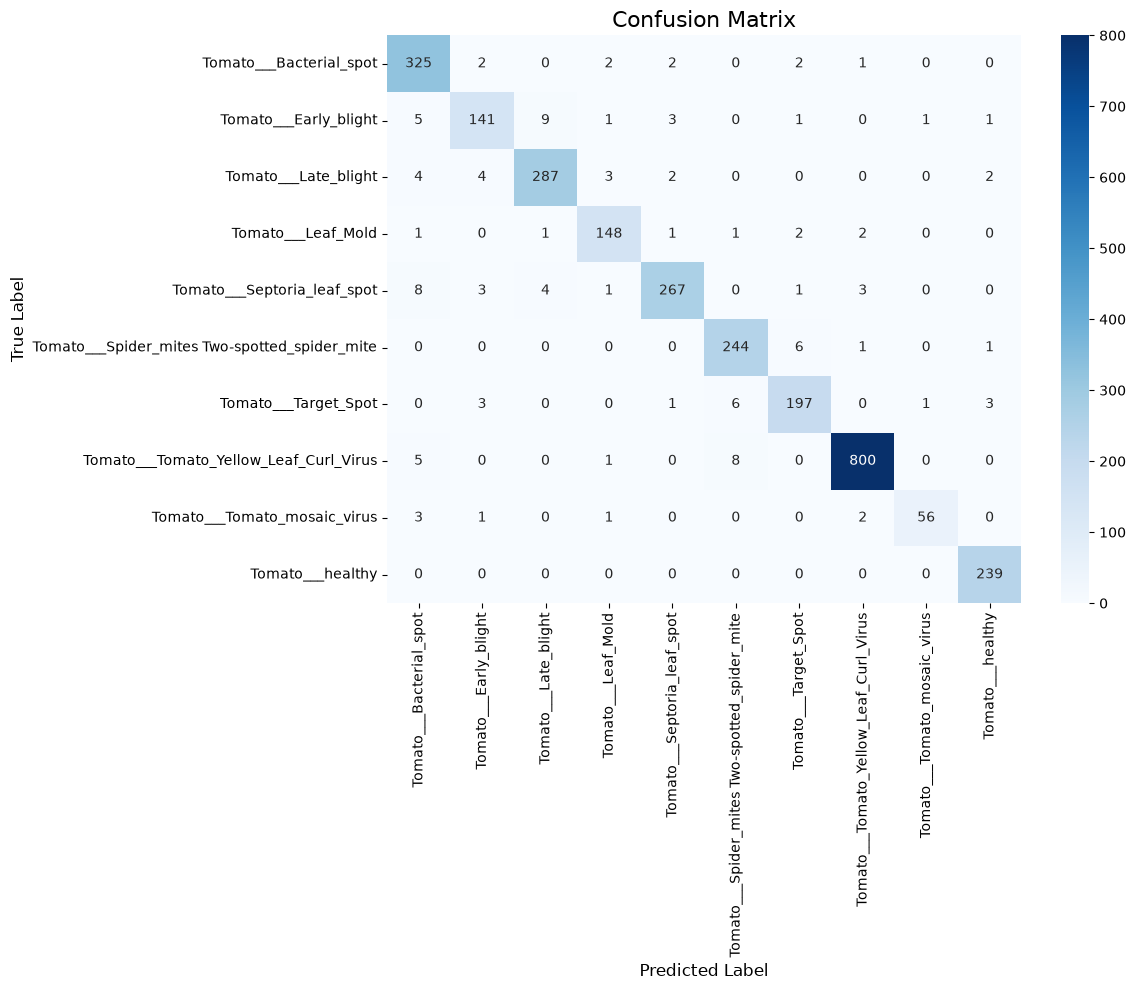

In [8]:
# ==========================================
# Step 8 : Generate Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

# Plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix", fontsize=16)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

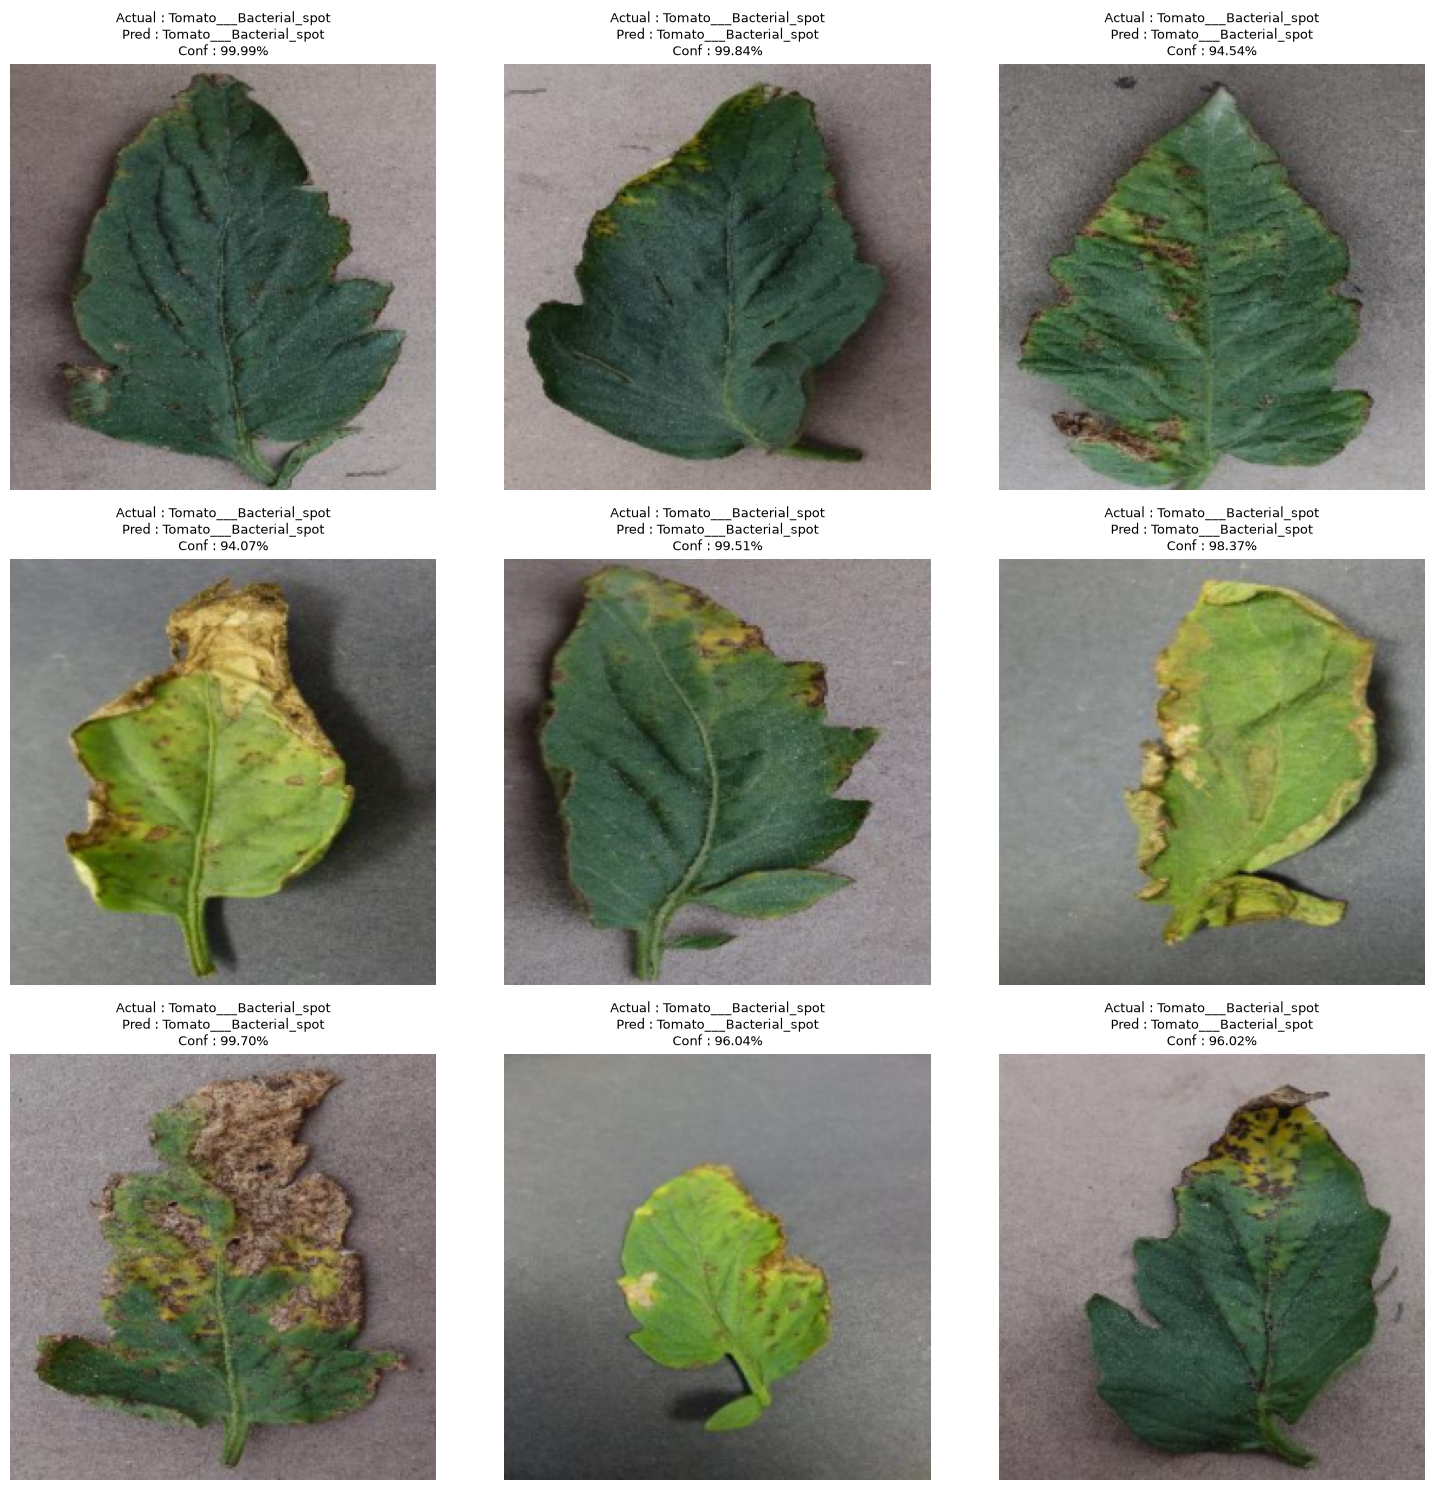

In [9]:
# ==========================================
# Step 9 : Display Sample Predictions
# ==========================================

import matplotlib.pyplot as plt
import torch

# Number of images to display
num_images = 9

# Get one batch from test loader
images, labels = next(iter(test_loader))

images = images.to(device)

# Prediction
model.eval()

with torch.no_grad():

    outputs = model(images)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, predictions = torch.max(probabilities, dim=1)

# Move to CPU
images = images.cpu()
labels = labels.cpu()
predictions = predictions.cpu()
confidence = confidence.cpu()

# Display images
plt.figure(figsize=(15, 15))

for i in range(num_images):

    plt.subplot(3, 3, i + 1)

    img = images[i].permute(1, 2, 0).numpy()

    # Undo ImageNet normalization
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    img = img * std + mean
    img = img.clip(0, 1)

    plt.imshow(img)

    actual = class_names[labels[i]]
    predicted = class_names[predictions[i]]
    conf = confidence[i].item() * 100

    plt.title(
        f"Actual : {actual}\n"
        f"Pred : {predicted}\n"
        f"Conf : {conf:.2f}%",

        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# Step 10 : Create Prediction Function
# ==========================================

from PIL import Image
import torch
from torchvision import transforms

# Image preprocessing (same as validation/test)
prediction_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_image(image_path):
    """
    Predict disease from a single tomato leaf image.

    Args:
        image_path (str): Path to image

    Returns:
        predicted_class (str)
        confidence (float)
    """

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply preprocessing
    image = prediction_transform(image)

    # Add batch dimension
    image = image.unsqueeze(0).to(device)

    # Evaluation mode
    model.eval()

    with torch.no_grad():

        outputs = model(image)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

    predicted_class = class_names[prediction.item()]
    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score

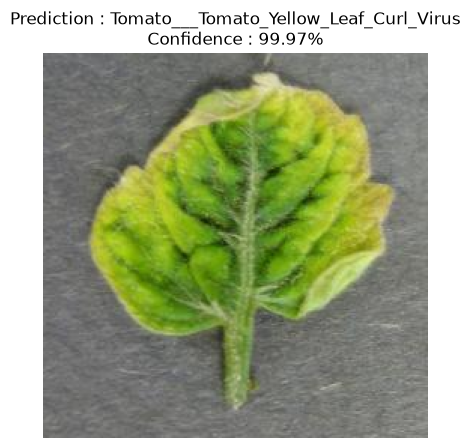

Prediction Result
Disease   : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Confidence: 99.97%


In [13]:
# ==========================================
# Step 11 : Test Prediction Function
# ==========================================

import matplotlib.pyplot as plt
from PIL import Image

# Your test image
image_path = r"D:\major project\dataset_split\test\Tomato___Tomato_Yellow_Leaf_Curl_Virus\0efaf7db-e814-4528-bfd9-eeda31d69d13___UF.GRC_YLCV_Lab 02888.JPG"

# Predict
predicted_class, confidence = predict_image(image_path)

# Display image
image = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction : {predicted_class}\n"
    f"Confidence : {confidence:.2f}%",
    fontsize=12
)

plt.show()

print("=" * 60)
print("Prediction Result")
print("=" * 60)
print("Disease   :", predicted_class)
print(f"Confidence: {confidence:.2f}%")
print("=" * 60)

In [14]:
# ==========================================
# Step 12 : Save Class Names
# ==========================================

import json
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save class names
with open("models/class_names.json", "w") as file:
    json.dump(class_names, file, indent=4)

print("✅ Class names saved successfully!")
print("Location: models/class_names.json")

✅ Class names saved successfully!
Location: models/class_names.json
